In [1]:
# Data manipulation
import pandas as pd
import numpy as np 
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Preprocessing
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
# 🧪 Model selection & evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score,
    f1_score, 
    classification_report,
    confusion_matrix,
    roc_curve, 
    auc
)

In [4]:
#  Handling imbalance
from imblearn.over_sampling import SMOTE
from collections import Counter


#### Loading the preprocessed data

In [5]:
data = pd.read_csv('Stroke_preprocessed.csv')
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5104,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5105,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5106,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5107,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


#### Train test split

In [6]:
X = data.drop(['stroke'],axis=1)            
y = data['stroke']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y,  random_state=42)

#### Separating numarical and categorical features

In [8]:
data_cat = X_train.select_dtypes(exclude=[np.number]).columns #selects categorical columns (non-numeric).
data_num = X_train.select_dtypes(include=np.number).columns     #selects numeric columns (integers, floats).
data_stroke = data['stroke'].copy()




### data resampling

In [9]:
smote = SMOTE(sampling_strategy={1: 350}, random_state=42)

#### Scaling data

In [10]:

#scaler = StandardScaler()
#Scaled_data = data_num.copy()


#Scaled_data = scaler.fit_transform(Scaled_data)
## we wil apply pipeline insted of encodding and scalling 

#### Fixing Text and Categorical Attributes


In [11]:

#cat_encodder = OneHotEncoder(sparse_output = False)  #sparse_output=False means it returns a dense NumPy array, not a sparse matrix.

#dat_cat_1hot = cat_encodder.fit_transform(data_cat)

#encoded_cols = cat_encodder.get_feature_names_out(data_cat.columns)                     #Get encoded column names
#df_cat_encoded = pd.DataFrame(dat_cat_1hot, columns=encoded_cols, index=data_cat.index) # Convert to DataFrame


#we wil apply pipeline insted of encodding and scalling 

In [12]:

#data_Conc = pd.concat([data_num, df_cat_encoded, data_stroke ], axis=1)               # Combine encoded data with scalled numeric data
#data_Conc

#features = list(data_Conc.columns)  # Creating a list of our features for future use
#features

#### Pipleline 

In [13]:
# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), data_num),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), data_cat),
])

## choosing best model

### Descion tree

In [14]:
from sklearn.tree import DecisionTreeClassifier

In [15]:
tree_clf = DecisionTreeClassifier(random_state=42,class_weight="balanced")

In [16]:
from imblearn.pipeline import Pipeline   # use this, not sklearn.pipeline so you can add smote in the pipline

pip_tree_clf = Pipeline([            #Pipeline  applies transform then fit/predict when you call .fit() or .predict().
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("classifier ", tree_clf )
    ])


In [17]:
pip_tree_clf.fit(X_train,y_train) # Applies the preprocessing steps (preprocessor) on X_train.
                                  #Passes the transformed data to the DecisionTreeClassifier.

# don’t need to scale or encode X_train and X_test manually.
# as You already wrapped preprocessing (StandardScaler + OneHotEncoder) inside a Pipeline via ColumnTransformer.

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42, sampling_strategy={1: 350})),
                ('classifier ',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [18]:
pip_tree_clf_prediction = pip_tree_clf.predict(X_test)

In [19]:
print(accuracy_score(y_test, pip_tree_clf_prediction))

0.9055772994129159


In [20]:
print(classification_report(y_test, pip_tree_clf_prediction))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1944
           1       0.07      0.08      0.08       100

    accuracy                           0.91      2044
   macro avg       0.51      0.51      0.51      2044
weighted avg       0.91      0.91      0.91      2044



### Random forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
rnd_clf = RandomForestClassifier(random_state=42,class_weight="balanced")

In [23]:
pip_rnd_clf = Pipeline([            #Pipeline  applies transform then fit/predict when you call .fit() or .predict().
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("classifier ", rnd_clf )
    ])

In [24]:
pip_rnd_clf.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42, sampling_strategy={1: 350})),
                ('classifier ',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [25]:
pip_rnd_clf_prediction = pip_rnd_clf.predict(X_test)

In [26]:
print(accuracy_score(pip_rnd_clf_prediction, y_test))

0.950587084148728


In [27]:
print(classification_report(y_test, pip_rnd_clf_prediction))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1944
           1       0.44      0.04      0.07       100

    accuracy                           0.95      2044
   macro avg       0.70      0.52      0.52      2044
weighted avg       0.93      0.95      0.93      2044



### SVM Classifier

In [28]:
from sklearn.svm import SVC

In [29]:
svc_clf = SVC(probability=True,random_state=42,class_weight="balanced") # probability=True to apply predict_proba 

In [30]:
pip_svc_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("classifier", svc_clf)
])

In [31]:
pip_svc_clf.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42, sampling_strategy={1: 350})),
                ('classifier',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

In [32]:
pip_svc_clf_prediction = pip_svc_clf.predict(X_test)

In [33]:
print(classification_report(y_test,pip_svc_clf_prediction))

              precision    recall  f1-score   support

           0       0.97      0.79      0.87      1944
           1       0.13      0.59      0.21       100

    accuracy                           0.78      2044
   macro avg       0.55      0.69      0.54      2044
weighted avg       0.93      0.78      0.84      2044



In [34]:
print(accuracy_score(pip_svc_clf_prediction, y_test))

0.7783757338551859


### Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:
lreg_clf = LogisticRegression(random_state=42,class_weight="balanced")

In [37]:
pip_lreg_clf = Pipeline([
    ('preprocessor',preprocessor),
    ("smote", smote),
    ('classifier',lreg_clf)
])


In [38]:
pip_lreg_clf.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42, sampling_strategy={1: 350})),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [39]:
pip_lreg_clf_prediction = pip_lreg_clf.predict(X_test) 

In [40]:
print(accuracy_score(y_test,pip_lreg_clf_prediction))

0.7407045009784736


In [41]:
print(classification_report(y_test,pip_lreg_clf_prediction))

              precision    recall  f1-score   support

           0       0.98      0.74      0.84      1944
           1       0.13      0.78      0.23       100

    accuracy                           0.74      2044
   macro avg       0.56      0.76      0.54      2044
weighted avg       0.94      0.74      0.81      2044



### Visualization of results 

In [42]:
def evaluate_model_df(model,  X_test, y_test, name="model"): 
    # Predictions (on test set)
    y_pred = model.predict(X_test)
    
    # Metrics as a dictionary
    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0)
    }
    
    return results

In [43]:
# Collect results for all models
results = []
results.append(evaluate_model_df(pip_lreg_clf, X_test, y_test, "Logistic Regression"))
results.append(evaluate_model_df(pip_svc_clf, X_test, y_test, "SVM Classifier"))
results.append(evaluate_model_df(pip_tree_clf, X_test, y_test, "Decision Tree"))
results.append(evaluate_model_df(pip_rnd_clf, X_test, y_test, "Random Forest"))

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression  0.740705   0.133106    0.78  0.227405
1       SVM Classifier  0.778376   0.125265    0.59  0.206655
2        Decision Tree  0.905577   0.073394    0.08  0.076555
3        Random Forest  0.950587   0.444444    0.04  0.073394


In [44]:
#The main goal = detect as many stroke cases as possible (catch the positives). That means you care most about Recall
#If Recall is low → you’re missing actual stroke cases (false negatives), which is dangerous in a medical-like scenario.
#If Precision is low → you’ll have more false alarms (healthy people flagged as stroke risk). That’s annoying, but not deadly.

<Figure size 600x500 with 0 Axes>

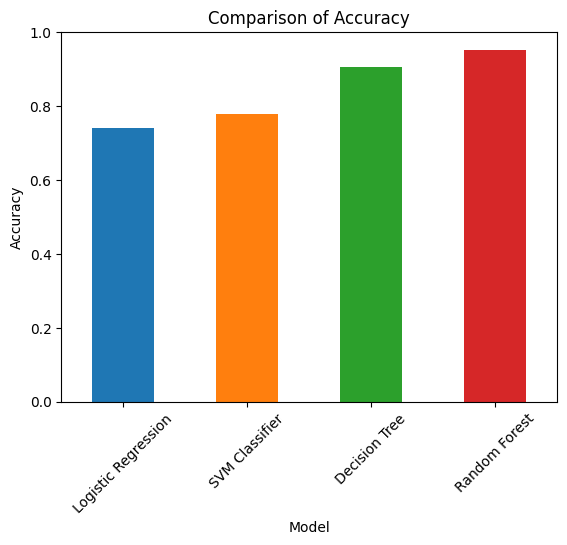

<Figure size 600x500 with 0 Axes>

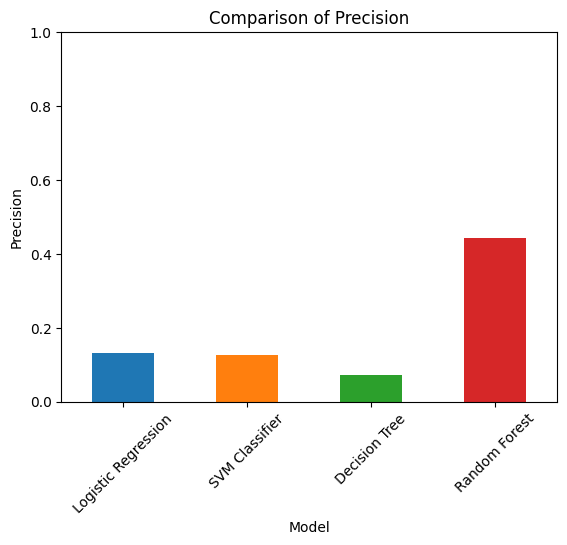

<Figure size 600x500 with 0 Axes>

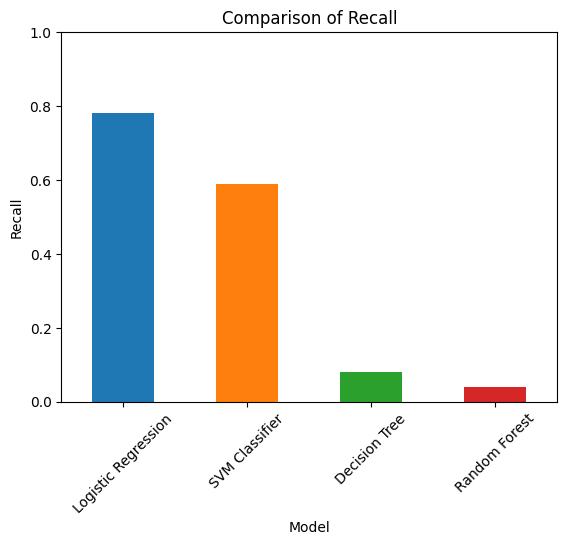

<Figure size 600x500 with 0 Axes>

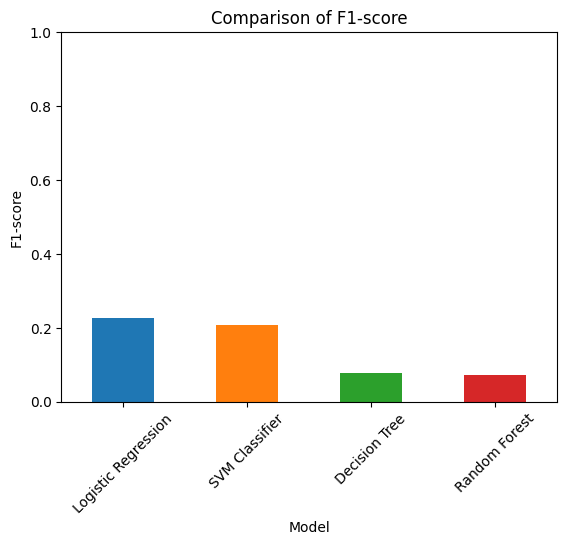

In [45]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

# Unique colors per model
model_colors = dict(zip(results_df["Model"].unique(), plt.cm.tab10.colors))

# Plot each metric separately
for metric in metrics:
    plt.figure(figsize=(6, 5))
    results_df.plot(
        kind="bar",
        x="Model",
        y=metric,
        legend=False,
        color=[model_colors[m] for m in results_df["Model"]]
    )
    plt.title(f"Comparison of {metric}")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.ylim(0, 1)  # classification metrics are between 0 and 1
    plt.xticks(rotation=45)
    plt.show()

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_curve(model, X_test, y_test, model_name):
    # Predict probabilities (for class 1 = stroke)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Get precision-recall pairs
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)

    # Plot curve
    plt.plot(recalls, precisions, label=f"{model_name} (AP={avg_precision:.2f})")




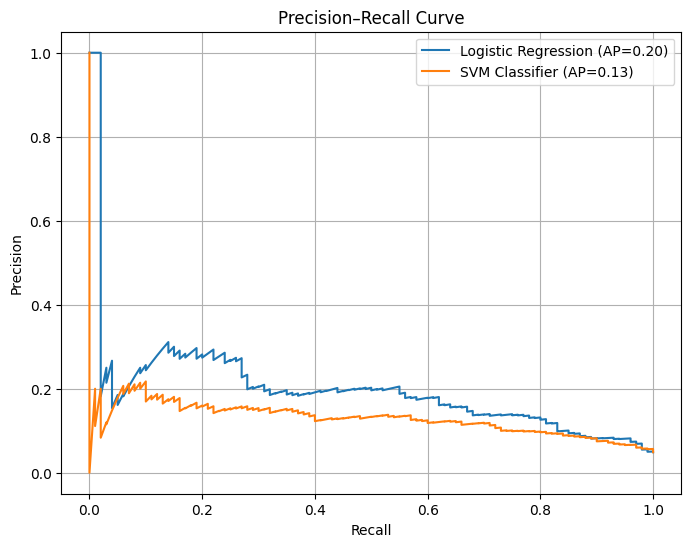

In [47]:
# Plot both Logistic Regression and SVM
plt.figure(figsize=(8,6))
plot_pr_curve(pip_lreg_clf, X_test, y_test, "Logistic Regression")
plot_pr_curve(pip_svc_clf, X_test, y_test, "SVM Classifier")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

## Logistic regression tuning 

In [48]:
from scipy.stats import randint, uniform


param_grid = { 
    'classifier__penalty': ['l1', 'l2', 'elasticnet', 'none'],  #add (classifier__) as a prefix to specify the step in the pipeline
    'classifier__C': uniform(0.01, 10),
    'classifier__solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'classifier__max_iter': randint(100, 500)
}


In [49]:
from sklearn.model_selection import RandomizedSearchCV
lreg_clf_rand = RandomizedSearchCV(
 estimator = pip_lreg_clf,
 param_distributions = param_grid,
 n_iter = 100, # Number of parameter settings that are sampled
 cv = 5,       # Number of cross-validation folds
 verbose=2,    # Controls the verbosity of the output

 n_jobs= -1   # Use all available CPU cores
)

In [50]:
lreg_clf_rand.fit(X_train,y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


c:\Users\AFRAAD-PC1\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
275 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\AFRAAD-PC1\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\AFRAAD-PC1\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\U

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_statu...
                   param_distributions={'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000002602A2A2190>,
                                        'classifier__max_iter': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002602A3A1650>,
                                        'classifier__penalty': ['l1', 'l2',
                                                                'elasticnet',
                                                                'none'],
                                        'classifier__solver': ['newton-cg',
                                                               'lbfgs',
                                                               'liblinear',
                                                               'sag', 'saga']},
                   verbose=2)

In [51]:
print ("Best parameters", lreg_clf_rand.best_params_) 

Best parameters {'classifier__C': np.float64(0.0812325629272914), 'classifier__max_iter': 163, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}


In [52]:
best_lreg_model = lreg_clf_rand.best_estimator_

In [53]:
best_lreg_model_prediction = best_lreg_model.predict(X_test)    

In [54]:
print(classification_report(y_test,best_lreg_model_prediction))

              precision    recall  f1-score   support

           0       0.98      0.74      0.84      1944
           1       0.13      0.78      0.23       100

    accuracy                           0.74      2044
   macro avg       0.56      0.76      0.53      2044
weighted avg       0.94      0.74      0.81      2044



In [55]:
print(accuracy_score(best_lreg_model_prediction,y_test)) 

0.737279843444227


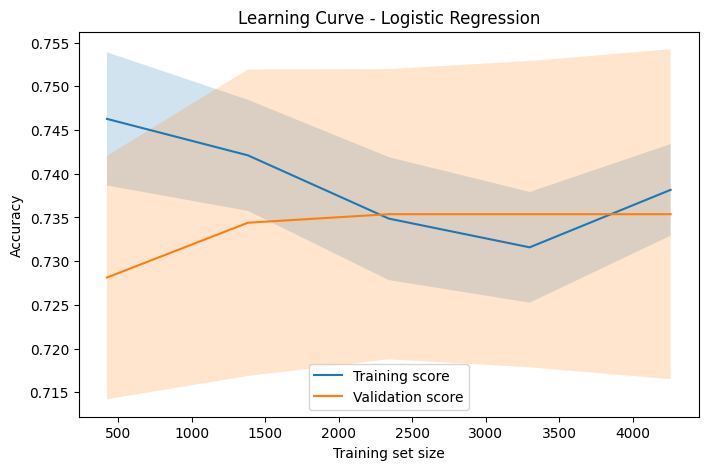

In [56]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    best_lreg_model, X, y, cv=6, scoring="accuracy", n_jobs=-1
)

# Mean & std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, val_mean, label="Validation score")

plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2)

plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Learning Curve - Logistic Regression")
plt.show()
